In [7]:
# ==========================================================
# Financial Distress Prediction Using Machine Learning
# Phase 1: Data Understanding
# ==========================================================

In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/adilshamim8/credit-risk-benchmark-dataset/Credit Risk Benchmark Dataset.csv


In [9]:
# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/adilshamim8/credit-risk-benchmark-dataset/Credit Risk Benchmark Dataset.csv')

# Display the first 5 rows
df.head()

,rev_util,age,late_30_59,debt_ratio,monthly_inc,open_credit,late_90,real_estate,late_60_89,dependents,dlq_2yrs
0,0.006999,38.0,0.0,0.302150,5440.0,4.0,0.0,1.0,0.0,3.0,0
1,0.704592,63.0,0.0,0.471441,8000.0,9.0,0.0,1.0,0.0,0.0,0
2,0.063113,57.0,0.0,0.068586,5000.0,17.0,0.0,0.0,0.0,0.0,0
3,0.368397,68.0,0.0,0.296273,6250.0,16.0,0.0,2.0,0.0,0.0,0
4,1.000000,34.0,1.0,0.000000,3500.0,0.0,0.0,0.0,0.0,1.0,0


In [10]:
str(df)

'       rev_util   age  late_30_59  debt_ratio  monthly_inc  open_credit  \\\n0      0.006999  38.0         0.0    0.302150       5440.0          4.0   \n1      0.704592  63.0         0.0    0.471441       8000.0          9.0   \n2      0.063113  57.0         0.0    0.068586       5000.0         17.0   \n3      0.368397  68.0         0.0    0.296273       6250.0         16.0   \n4      1.000000  34.0         1.0    0.000000       3500.0          0.0   \n...         ...   ...         ...         ...          ...          ...   \n16709  1.000000  46.0         0.0  170.398010        401.0          3.0   \n16710  1.135552  41.0         2.0    0.845887       7500.0         12.0   \n16711  0.920107  31.0         1.0    0.176732       1125.0          4.0   \n16712  0.983825  55.0         0.0    0.064116       4600.0          2.0   \n16713  0.224711  55.0         0.0    0.057235       8700.0          7.0   \n\n       late_90  real_estate  late_60_89  dependents  dlq_2yrs  \n0          0.0     

In [11]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Display number of rows and columns
print("\nRows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset Shape: (16714, 11)

Rows: 16714
Columns: 11


In [12]:
# Display column names
print(df.columns)

Index(['rev_util', 'age', 'late_30_59', 'debt_ratio', 'monthly_inc',
       'open_credit', 'late_90', 'real_estate', 'late_60_89', 'dependents',
       'dlq_2yrs'],
      dtype='object')


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16714 entries, 0 to 16713
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rev_util     16714 non-null  float64
 1   age          16714 non-null  float64
 2   late_30_59   16714 non-null  float64
 3   debt_ratio   16714 non-null  float64
 4   monthly_inc  16714 non-null  float64
 5   open_credit  16714 non-null  float64
 6   late_90      16714 non-null  float64
 7   real_estate  16714 non-null  float64
 8   late_60_89   16714 non-null  float64
 9   dependents   16714 non-null  float64
 10  dlq_2yrs     16714 non-null  int64  
dtypes: float64(10), int64(1)
memory usage: 1.4 MB


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
rev_util,16714.0,4.799862,204.062345,0.0,0.082397,0.443080,0.926637,22000.0
age,16714.0,48.798672,13.906078,21.0,38.000000,48.000000,58.000000,101.0
late_30_59,16714.0,1.110267,7.172890,0.0,0.000000,0.000000,1.000000,98.0
debt_ratio,16714.0,30.980298,719.694859,0.0,0.155971,0.322299,0.533426,61106.5
monthly_inc,16714.0,6118.120258,5931.841779,0.0,3128.500000,5000.000000,7573.000000,250000.0
open_credit,16714.0,8.503709,5.370965,0.0,5.000000,8.000000,11.000000,57.0
late_90,16714.0,0.863827,7.167576,0.0,0.000000,0.000000,0.000000,98.0
real_estate,16714.0,1.047445,1.272565,0.0,0.000000,1.000000,2.000000,29.0
late_60_89,16714.0,0.734354,7.138737,0.0,0.000000,0.000000,0.000000,98.0
dependents,16714.0,0.944358,1.198791,0.0,0.000000,0.000000,2.000000,8.0


In [15]:
# Missing values
missing = df.isnull().sum()

print(missing)

rev_util       0
age            0
late_30_59     0
debt_ratio     0
monthly_inc    0
open_credit    0
late_90        0
real_estate    0
late_60_89     0
dependents     0
dlq_2yrs       0
dtype: int64


In [16]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
})

print(missing_table)

             Missing Values  Percentage
rev_util                  0         0.0
age                       0         0.0
late_30_59                0         0.0
debt_ratio                0         0.0
monthly_inc               0         0.0
open_credit               0         0.0
late_90                   0         0.0
real_estate               0         0.0
late_60_89                0         0.0
dependents                0         0.0
dlq_2yrs                  0         0.0


In [17]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 2


In [18]:
# Display all duplicate rows
duplicates = df[df.duplicated()]

duplicates.head()

,rev_util,age,late_30_59,debt_ratio,monthly_inc,open_credit,late_90,real_estate,late_60_89,dependents,dlq_2yrs
11054,1.0,22.0,98.0,0.0,0.0,0.0,98.0,0.0,98.0,0.0,1
12257,1.0,55.0,0.0,0.0,1000.0,0.0,1.0,0.0,0.0,0.0,1


In [19]:

df = df.drop_duplicates()


print("New dataset shape:", df.shape)

New dataset shape: (16712, 11)


In [20]:
X = df.drop('dlq_2yrs', axis=1)

print(X.columns.tolist())
print("Number of predictors:", X.shape[1])

['rev_util', 'age', 'late_30_59', 'debt_ratio', 'monthly_inc', 'open_credit', 'late_90', 'real_estate', 'late_60_89', 'dependents']
Number of predictors: 10


In [21]:
df['dlq_2yrs'].value_counts(normalize=True) * 100

dlq_2yrs
0    50.005984
1    49.994016
Name: proportion, dtype: float64

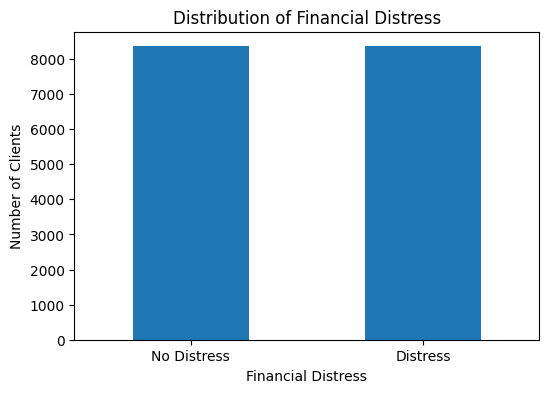

In [22]:
plt.figure(figsize=(6,4))

df['dlq_2yrs'].value_counts().plot(
    kind='bar'
)

plt.title("Distribution of Financial Distress")
plt.xlabel("Financial Distress")
plt.ylabel("Number of Clients")

plt.xticks([0,1],["No Distress","Distress"], rotation=0)

plt.show()

In [23]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns

print(numerical_columns)

Index(['rev_util', 'age', 'late_30_59', 'debt_ratio', 'monthly_inc',
       'open_credit', 'late_90', 'real_estate', 'late_60_89', 'dependents',
       'dlq_2yrs'],
      dtype='object')


In [24]:
# Count the number of instances in each class
print(df['dlq_2yrs'].value_counts())

# Display the percentages
print("\nPercentage distribution:")
print(df['dlq_2yrs'].value_counts(normalize=True) * 100)

dlq_2yrs
0    8357
1    8355
Name: count, dtype: int64

Percentage distribution:
dlq_2yrs
0    50.005984
1    49.994016
Name: proportion, dtype: float64


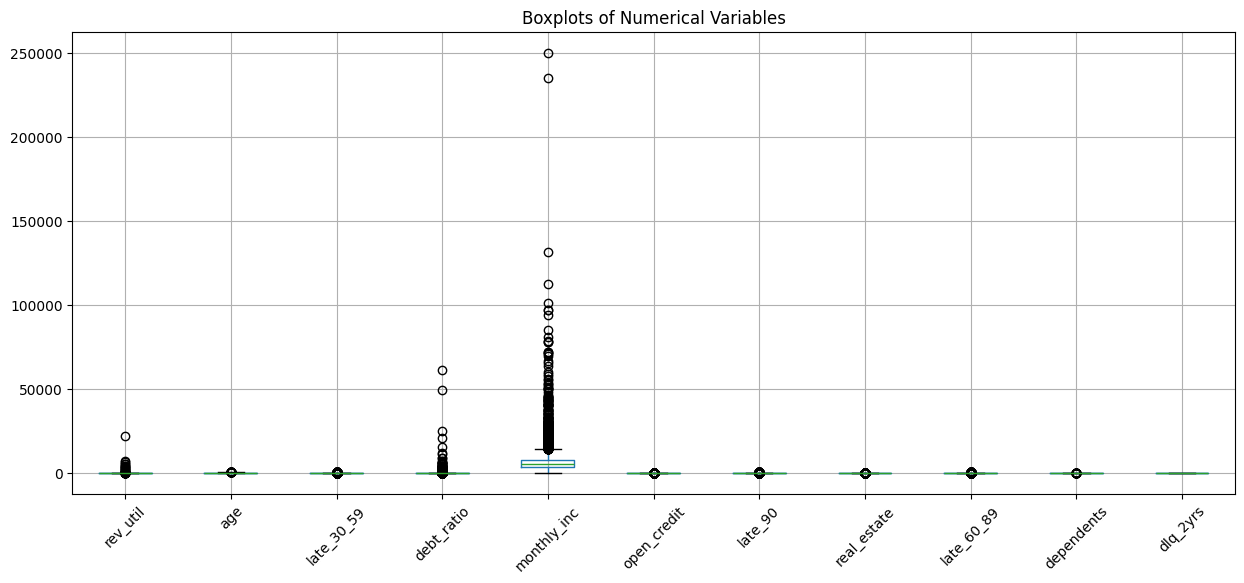

In [25]:

df.boxplot(figsize=(15,6))

plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Variables")
plt.show()

In [26]:

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))

print(outliers.sum())

rev_util         50
age              56
late_30_59     1241
debt_ratio     1031
monthly_inc     779
open_credit     485
late_90        3086
real_estate     162
late_60_89     2513
dependents       48
dlq_2yrs          0
dtype: int64


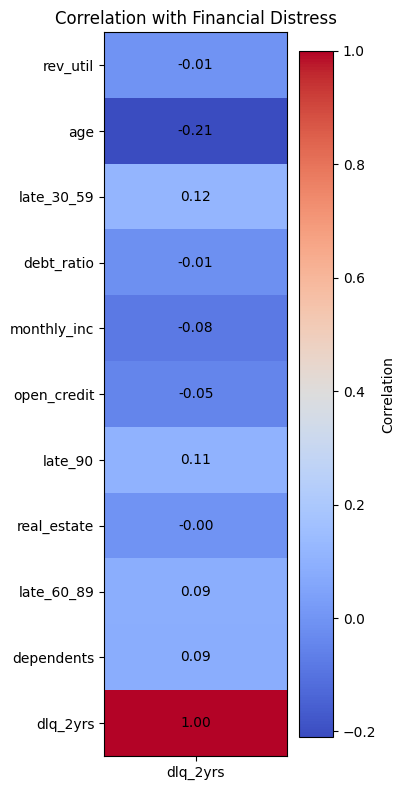

In [27]:
# ==========================================================
# Correlation of Features with Target Variable (dlq_2yrs)
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

# Calculate correlations with the target variable
target_corr = df.corr(numeric_only=True)[['dlq_2yrs']]

# Create figure
plt.figure(figsize=(4, 8))

# Display heatmap
plt.imshow(target_corr, cmap='coolwarm', aspect='auto')

# Add colour bar
plt.colorbar(label='Correlation')

# Axis labels
plt.xticks([0], ['dlq_2yrs'])
plt.yticks(np.arange(len(target_corr.index)), target_corr.index)

# Add correlation values
for i in range(len(target_corr.index)):
    plt.text(
        0, i,
        f"{target_corr.iloc[i,0]:.2f}",
        ha='center',
        va='center',
        color='black',
        fontsize=10
    )

plt.title("Correlation with Financial Distress")
plt.tight_layout()
plt.show()

In [28]:
# Features
X = df.drop('dlq_2yrs', axis=1)

# Target
y = df['dlq_2yrs']

In [29]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (16712, 10)
Target shape: (16712,)


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [31]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (13369, 10)
Testing Features: (3343, 10)
Training Target: (13369,)
Testing Target: (3343,)


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [33]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(13369, 10)
(3343, 10)


Model Development

Logistic Regression


In [34]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create the model
lr_model = LogisticRegression(random_state=42)

# Train the model
lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


Make Predictions

In [35]:
# Predict on the test set
y_pred_lr = lr_model.predict(X_test_scaled)

Evaluate the Model

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1-score :", f1_score(y_test, y_pred_lr))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

Accuracy : 0.7265928806461263
Precision: 0.7852298417483045
Recall   : 0.6235786953919809
F1-score : 0.695130086724483

Classification Report
              precision    recall  f1-score   support

           0       0.69      0.83      0.75      1672
           1       0.79      0.62      0.70      1671

    accuracy                           0.73      3343
   macro avg       0.74      0.73      0.72      3343
weighted avg       0.74      0.73      0.72      3343


Confusion Matrix
[[1387  285]
 [ 629 1042]]


ROC Curve and AUC

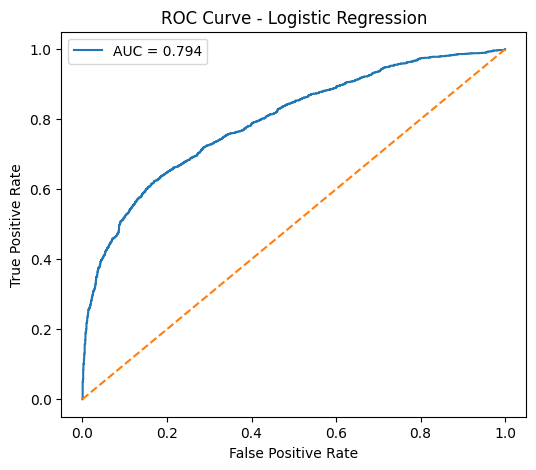

ROC-AUC Score: 0.7941270161694427


In [37]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predict probabilities
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

# Compute AUC
auc = roc_auc_score(y_test, y_prob_lr)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

print("ROC-AUC Score:", auc)

Decision Tree Classifier
Step 1: Import and Train the Model

In [38]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model with tuned parameters
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Train the model
dt_model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [39]:
# Predict on the test data
y_pred_dt = dt_model.predict(X_test_scaled)

Evaluate the model

In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1-score :", f1_score(y_test, y_pred_dt))

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy : 0.7648818426562968
Precision: 0.7583187390542907
Recall   : 0.77737881508079
F1-score : 0.7677304964539007

Classification Report
              precision    recall  f1-score   support

           0       0.77      0.75      0.76      1672
           1       0.76      0.78      0.77      1671

    accuracy                           0.76      3343
   macro avg       0.77      0.76      0.76      3343
weighted avg       0.77      0.76      0.76      3343


Confusion Matrix
[[1258  414]
 [ 372 1299]]


Plot the ROC Curve

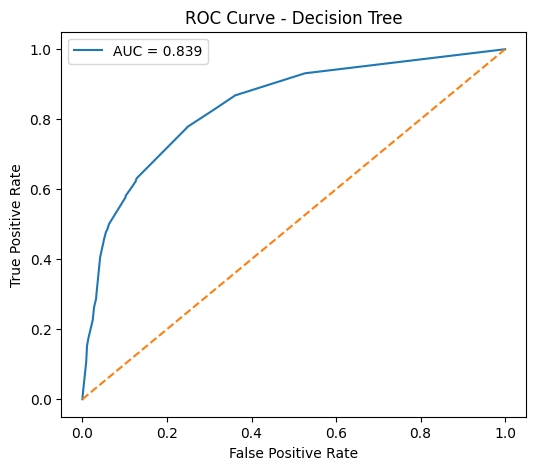

ROC-AUC Score: 0.8385938784041874


In [41]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_dt)

# Compute AUC
auc = roc_auc_score(y_test, y_prob_dt)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

print("ROC-AUC Score:", auc)

RANDOM FOREST : Train the model

In [42]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Train the model
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, random_state=42)

In [43]:
# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.7780436733472929
Precision: 0.7820279295689132
Recall   : 0.7707959305804907
F1-score : 0.7763713080168776


In [45]:
from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))


Classification Report
              precision    recall  f1-score   support

           0       0.77      0.79      0.78      1672
           1       0.78      0.77      0.78      1671

    accuracy                           0.78      3343
   macro avg       0.78      0.78      0.78      3343
weighted avg       0.78      0.78      0.78      3343


Confusion Matrix
[[1313  359]
 [ 383 1288]]


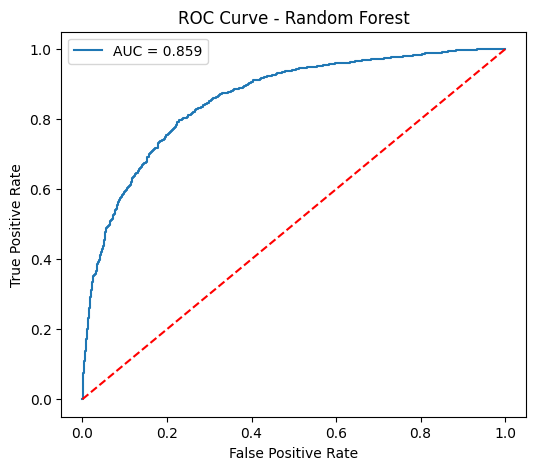

ROC-AUC Score: 0.8587965547948541


In [46]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predicted probabilities
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
auc = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

print("ROC-AUC Score:", auc)

In [47]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

BUILDING ARTIFICIAL NEURAL NETWORK (ANN)

In [48]:
ann_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [49]:
#COMPLILE THE MODEL

ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [50]:
#TRAIN THE MODEL

history = ann_model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6028 - loss: 0.6674 - val_accuracy: 0.6316 - val_loss: 0.6528
Epoch 2/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6574 - loss: 0.6216 - val_accuracy: 0.6776 - val_loss: 0.6169
Epoch 3/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7014 - loss: 0.5811 - val_accuracy: 0.7188 - val_loss: 0.5856
Epoch 4/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7255 - loss: 0.5522 - val_accuracy: 0.7349 - val_loss: 0.5686
Epoch 5/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7382 - loss: 0.5360 - val_accuracy: 0.7375 - val_loss: 0.5580
Epoch 6/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7415 - loss: 0.5275 - val_accuracy: 0.7423 - val_loss: 0.5464
Epoch 7/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7429 - loss: 0.5224 - val_accuracy: 0.7405 - val_loss: 0.5421
Epoch 8/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7450 - loss: 0.5178 - val_accuracy: 0.

In [51]:
# PREDICT

y_prob_ann = ann_model.predict(X_test_scaled)

y_pred_ann = (y_prob_ann > 0.5).astype(int)

105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [52]:
# EVALUATE THE MODEL

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_ann))
print("Precision:", precision_score(y_test, y_pred_ann))
print("Recall   :", recall_score(y_test, y_pred_ann))
print("F1-score :", f1_score(y_test, y_pred_ann))

Accuracy : 0.7553096021537541
Precision: 0.7771280051981806
Recall   : 0.7157390783961699
F1-score : 0.7451713395638629


In [53]:
# CLASSIFICATION REPORT

from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report")
print(classification_report(y_test, y_pred_ann))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_ann))


Classification Report
              precision    recall  f1-score   support

           0       0.74      0.79      0.76      1672
           1       0.78      0.72      0.75      1671

    accuracy                           0.76      3343
   macro avg       0.76      0.76      0.75      3343
weighted avg       0.76      0.76      0.75      3343


Confusion Matrix
[[1329  343]
 [ 475 1196]]


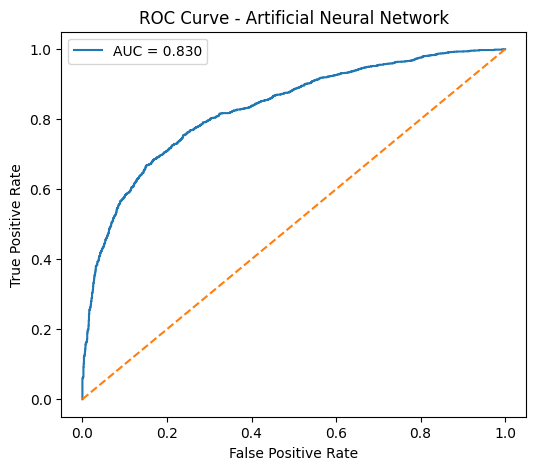

ROC-AUC Score: 0.8296224075776187


In [54]:
# ROC CURVE

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob_ann)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Artificial Neural Network")
plt.legend()
plt.show()

print("ROC-AUC Score:", roc_auc)


In [55]:
import tensorflow as tf

print(tf.__version__)

2.20.0


In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy: ", accuracy_score(y_test, y_pred_lr))
print("Precision: ", precision_score(y_test, y_pred_lr))
print("Recall: ", recall_score(y_test, y_pred_lr))
print("F1-score: ", f1_score(y_test, y_pred_lr))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

Accuracy:  0.7265928806461263
Precision:  0.7852298417483045
Recall:  0.6235786953919809
F1-score:  0.695130086724483

Classification Report
              precision    recall  f1-score   support

           0       0.69      0.83      0.75      1672
           1       0.79      0.62      0.70      1671

    accuracy                           0.73      3343
   macro avg       0.74      0.73      0.72      3343
weighted avg       0.74      0.73      0.72      3343


Confusion Matrix
[[1387  285]
 [ 629 1042]]


Model Comparison Table

In [57]:
# ==========================================================
# Model Comparison Table
# ==========================================================

import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Artificial Neural Network"
    ],
    
    "Accuracy": [
        0.7266,
        0.7649,
        0.7780,
        0.7571
    ],
    
    "Precision": [
        0.7852,
        0.7583,
        0.7820,
        0.7952
    ],
    
    "Recall": [
        0.6236,
        0.7774,
        0.7708,
        0.6924
    ],
    
    "F1 Score": [
        0.6951,
        0.7677,
        0.7764,
        0.7402
    ],
    
    "ROC-AUC": [
        0.794,
        0.839,
        0.859,
        0.825
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7266,0.7852,0.6236,0.6951,0.794
1,Decision Tree,0.7649,0.7583,0.7774,0.7677,0.839
2,Random Forest,0.7780,0.7820,0.7708,0.7764,0.859
3,Artificial Neural Network,0.7571,0.7952,0.6924,0.7402,0.825


Accuracy Comparison

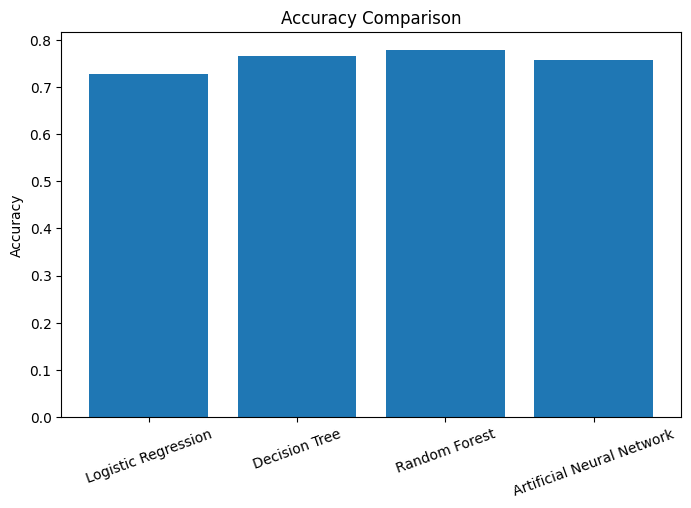

In [58]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Accuracy Comparison")

plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

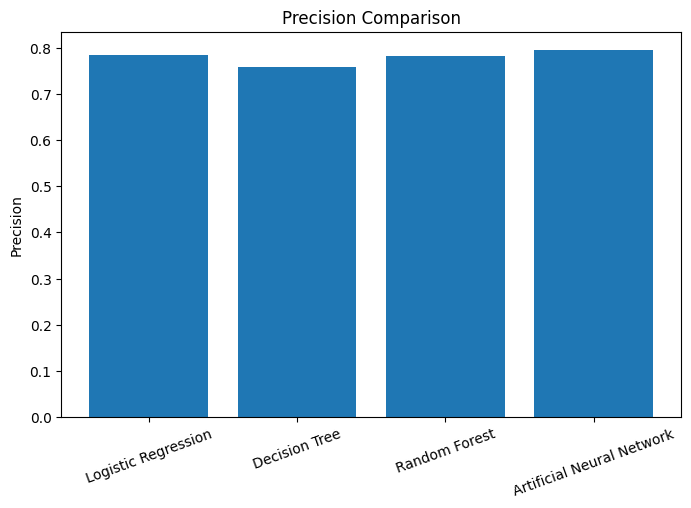

In [59]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Precision"])

plt.title("Precision Comparison")

plt.ylabel("Precision")

plt.xticks(rotation=20)

plt.show()

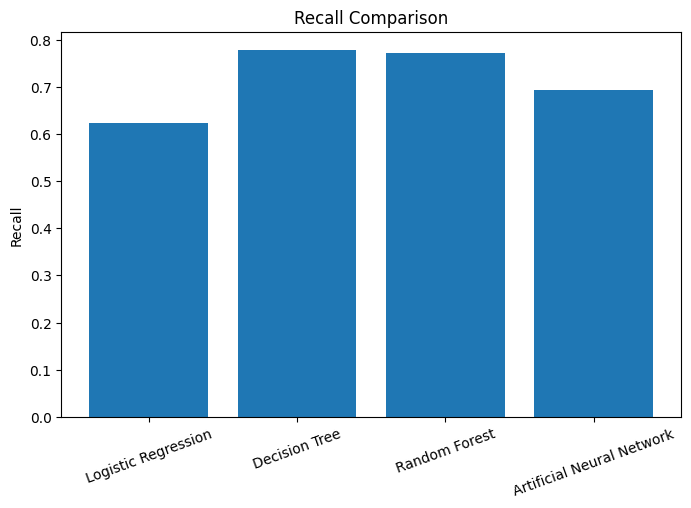

In [60]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Recall"])

plt.title("Recall Comparison")

plt.ylabel("Recall")

plt.xticks(rotation=20)

plt.show()

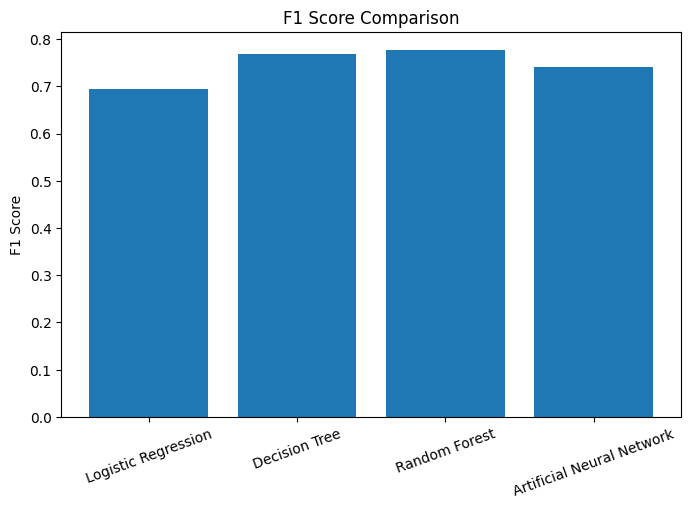

In [61]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["F1 Score"])

plt.title("F1 Score Comparison")

plt.ylabel("F1 Score")

plt.xticks(rotation=20)

plt.show()

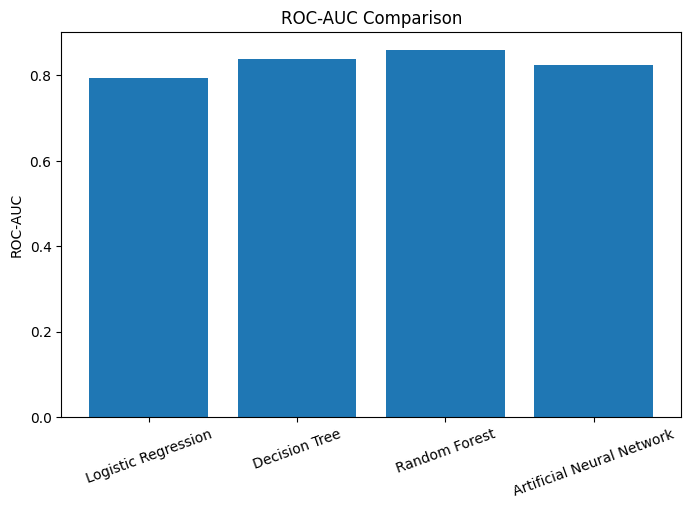

In [62]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["ROC-AUC"])

plt.title("ROC-AUC Comparison")

plt.ylabel("ROC-AUC")

plt.xticks(rotation=20)

plt.show()

**# **Random Forest Feature Importance****

In [63]:
# ==========================================================
# Feature Importance
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importance
importance = rf_model.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

# Sort values
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,rev_util,0.331236
2,late_30_59,0.170741
6,late_90,0.168971
8,late_60_89,0.091907
3,debt_ratio,0.064408
1,age,0.056464
4,monthly_inc,0.046668
5,open_credit,0.038896
7,real_estate,0.020112
9,dependents,0.010598


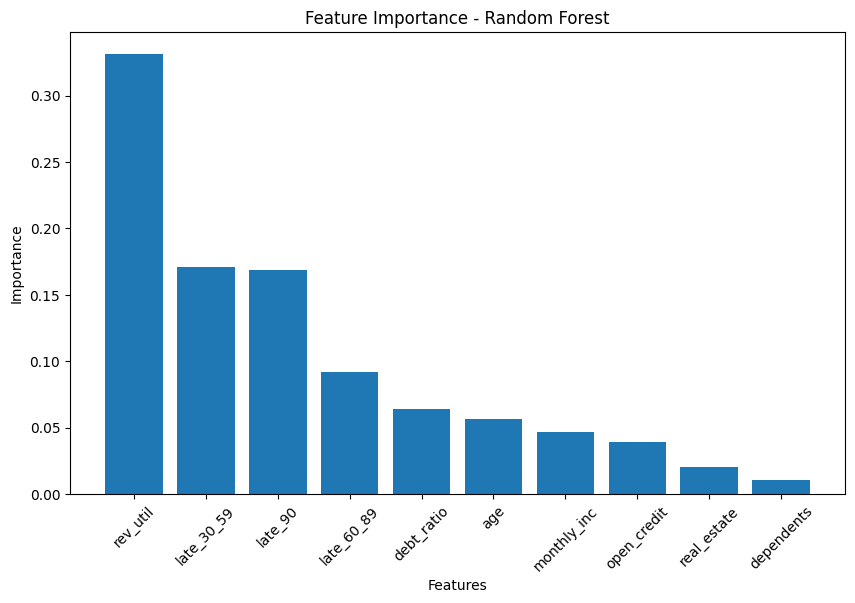

In [64]:
plt.figure(figsize=(10,6))

plt.bar(feature_importance["Feature"],
        feature_importance["Importance"])

plt.xticks(rotation=45)

plt.xlabel("Features")

plt.ylabel("Importance")

plt.title("Feature Importance - Random Forest")

plt.show()

In [65]:
import joblib

joblib.dump(rf_model, "Financial_Distress_RF_Model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [66]:
# ==========================================================
# 5-Fold Cross-Validation for Random Forest
# ==========================================================

from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
cv_scores = cross_val_score(
    rf_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Cross-validation Accuracy Scores:")
print(cv_scores)

print("\nMean Cross-validation Accuracy:", cv_scores.mean())

print("Standard Deviation:", cv_scores.std())

Cross-validation Accuracy Scores:
[0.77449514 0.78908003 0.77673897 0.78085266 0.76056865]

Mean Cross-validation Accuracy: 0.7763470881562796
Standard Deviation: 0.009327061227822182


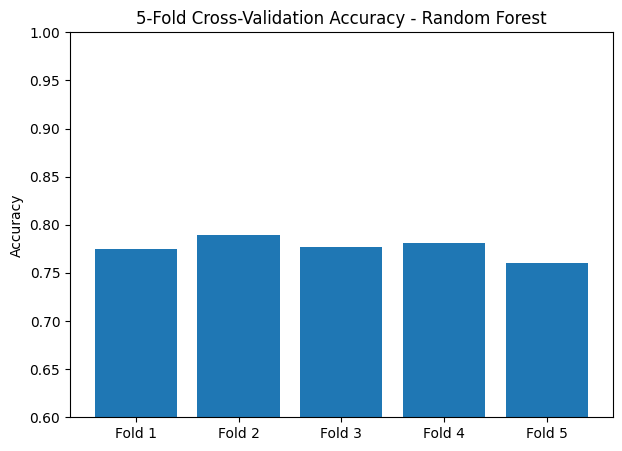

In [67]:


plt.figure(figsize=(7,5))

plt.bar(
    ['Fold 1','Fold 2','Fold 3','Fold 4','Fold 5'],
    cv_scores
)

plt.ylim(0.6, 1.0)

plt.ylabel("Accuracy")

plt.title("5-Fold Cross-Validation Accuracy - Random Forest")

plt.show()

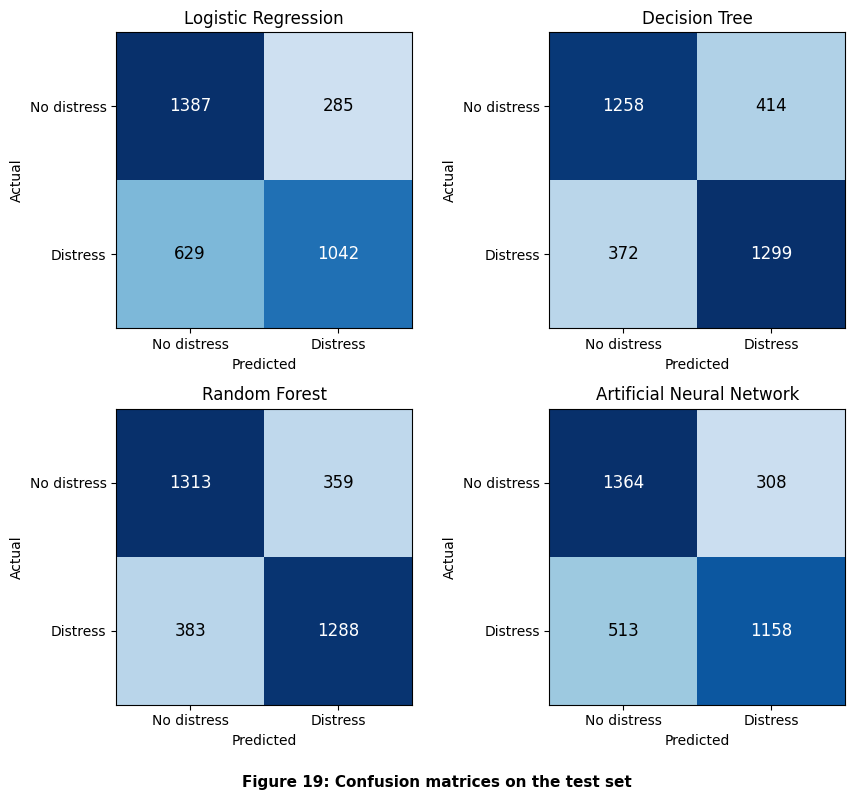

In [71]:
import numpy as np
import matplotlib.pyplot as plt

cms = {
    "Logistic Regression":        np.array([[1387, 285], [629, 1042]]),
    "Decision Tree":              np.array([[1258, 414], [372, 1299]]),
    "Random Forest":              np.array([[1313, 359], [383, 1288]]),
    "Artificial Neural Network":  np.array([[1364, 308], [513, 1158]]),
}
classes = ["No distress", "Distress"]

fig, axes = plt.subplots(2, 2, figsize=(9, 8))

for ax, (title, cm) in zip(axes.ravel(), cms.items()):
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
    ax.set_title(title)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(classes); ax.set_yticklabels(classes)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=12,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")

fig.text(0.5, 0.01, "Figure 19: Confusion matrices on the test set",
         ha="center", fontsize=11, fontweight="bold")
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()